# Flight Delay Prediction — Full Dataset 2024

**Mata Kuliah:** IF-3302 Analisis Mahadata  
**Dataset:** Flight Data 2024 (~7 juta record, **full data tanpa filter JFK, tanpa downsampling**)  
**Pipeline:** Local (Pandas + scikit-learn SGDClassifier) vs Spark-ML (PySpark + MLlib LogisticRegression)  
**Target:** `label = 1` jika `DepDelay > 15`, `label = 0` jika `DepDelay <= 15`


In [1]:
!pip install kagglehub pyspark scipy plotly ipywidgets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.7 MB/s eta 0:00:00


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Dictionary untuk menyimpan timing dan metrik
timings = {"Spark-ML": {}, "Local": {}}
metrics  = {"Spark-ML": {}, "Local": {}}

print("Imports OK")

Imports OK


## 1. Download Dataset

In [3]:
import kagglehub, glob

_t_dl = time.time()
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")
print("Dataset path:", path)

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
csv_files = [f for f in csv_files if "sample" not in f and "dictionary" not in f]
print("CSV files:", csv_files)
flight_csv = csv_files[0]
print("Using:", flight_csv)
print(f"Download time: {time.time()-_t_dl:.2f} s")

Using Colab cache for faster access to the 'flight-data-2024' dataset.
Dataset path: /kaggle/input/flight-data-2024
CSV files: ['/kaggle/input/flight-data-2024/flight_data_2024.csv']
Using: /kaggle/input/flight-data-2024/flight_data_2024.csv
Download time: 5.42 s


---
# BAGIAN A — Spark-ML Pipeline (PySpark + MLlib)

## A1. SparkSession & Data Loading

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext
from pyspark.sql.types import *
from pyspark.sql import Row
from pyspark.sql.functions import udf, col, when, isnan, count as F_count
from pyspark.sql.functions import floor as F_floor, avg as F_avg

_t0 = time.time()

spark = (
    SparkSession.builder
    .appName("FlightDelayFullData")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
sc = spark.sparkContext
sqlContext = SQLContext(sc)
sc.setLogLevel("ERROR")

print("Spark version:", spark.version)

Spark version: 4.0.2


In [5]:
import csv, io

def split_csv_line(line):
    return next(csv.reader(io.StringIO(line)))

textFile    = sc.textFile(flight_csv)
textFileRDD = textFile.map(split_csv_line)
header      = textFileRDD.first()
textRDD     = textFileRDD.filter(lambda r: r != header)

# Feature index reference (Flight Data 2024):
# 0 year, 1 month, 2 day_of_month, 3 day_of_week, 4 fl_date,
# 5 op_unique_carrier, 6 op_carrier_fl_num, 7 origin, 8 origin_city_name,
# 9 origin_state_nm, 10 dest, 11 dest_city_name, 12 dest_state_nm,
# 13 crs_dep_time, 14 dep_time, 15 dep_delay, 16 taxi_out, 17 wheels_off,
# 18 wheels_on, 19 taxi_in, 20 crs_arr_time, 21 arr_time, 22 arr_delay,
# 23 cancelled, 24 cancellation_code, 25 diverted, 26 crs_elapsed_time,
# 27 actual_elapsed_time, 28 air_time, 29 distance, ...

def parse(x):
    try:
        dep_delay_raw = x[15].strip()
        if not dep_delay_raw:          # skip baris tanpa DepDelay
            return None
        dep_delay = float(dep_delay_raw)
        y = Row(
            Month         = int(x[1]),
            DayofMonth    = int(x[2]),
            DayOfWeek     = int(x[3]),
            DepTime       = int(float(x[14])) if x[14].strip() else 0,
            CRSDepTime    = int(float(x[13])) if x[13].strip() else 0,
            ArrTime       = int(float(x[21])) if x[21].strip() else 0,
            CRSArrTime    = int(float(x[20])) if x[20].strip() else 0,
            UniqueCarrier = x[5],
            Origin        = x[7],
            Dest          = x[10],
            Distance      = int(float(x[29])) if x[29].strip() else 0,
            DepDelay      = dep_delay,
        )
    except Exception:
        return None
    return y

rowRDD = textRDD.map(parse).filter(lambda x: x is not None)
df     = sqlContext.createDataFrame(rowRDD)

# ─── Buat kolom label (1 jika DepDelay > 15) ─────────────────────────────────
df = df.withColumn("label", when(col("DepDelay") > 15, 1).otherwise(0).cast(IntegerType()))

# ─── Hanya pilih kolom yang dibutuhkan ───────────────────────────────────────
FEATURE_COLS_NUM  = ["Month", "DayofMonth", "DayOfWeek", "DepTime",
                     "CRSDepTime", "ArrTime", "CRSArrTime", "Distance"]
FEATURE_COLS_CAT  = ["UniqueCarrier", "Origin", "Dest"]
ALL_COLS          = FEATURE_COLS_NUM + FEATURE_COLS_CAT + ["DepDelay", "label"]

df = df.select(ALL_COLS)

# ─── Persist dengan MEMORY_AND_DISK — lebih aman untuk 7 juta baris ─────────
# Jika RAM tidak cukup, Spark otomatis spill sebagian data ke disk
from pyspark import StorageLevel
df = df.persist(StorageLevel.MEMORY_AND_DISK)
_n = df.count()   # trigger persist + hitung rows

timings["Spark-ML"]["data_loading"] = time.time() - _t0
print(f"[Spark-ML] Jumlah data awal (setelah drop null DepDelay): {_n:,}")
print(f"[Spark-ML] Data loading time: {timings['Spark-ML']['data_loading']:.2f} s")

[Spark-ML] Jumlah data awal (setelah drop null DepDelay): 6,986,111
[Spark-ML] Data loading time: 173.11 s


## A2. EDA — Skema & Statistik Deskriptif

In [6]:
df.printSchema()

root
 |-- Month: long (nullable = true)
 |-- DayofMonth: long (nullable = true)
 |-- DayOfWeek: long (nullable = true)
 |-- DepTime: long (nullable = true)
 |-- CRSDepTime: long (nullable = true)
 |-- ArrTime: long (nullable = true)
 |-- CRSArrTime: long (nullable = true)
 |-- Distance: long (nullable = true)
 |-- UniqueCarrier: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- label: integer (nullable = false)



In [7]:
df.select("Month", "DayofMonth", "DayOfWeek", "DepDelay", "Distance").summary(
    "count", "mean", "stddev", "min", "max"
).show()

+-------+------------------+------------------+------------------+------------------+-----------------+
|summary|             Month|        DayofMonth|         DayOfWeek|          DepDelay|         Distance|
+-------+------------------+------------------+------------------+------------------+-----------------+
|  count|           6986111|           6986111|           6986111|           6986111|          6986111|
|   mean|6.5966668723127935|15.790920012579244|3.9815058764454214| 12.67708199884027|834.1954988977416|
| stddev| 3.396728587991843| 8.795478176905434|2.0123432122539144|56.059970271063015|596.6682756024999|
|    min|                 1|                 1|                 1|             -96.0|               11|
|    max|                12|                31|                 7|            3777.0|             5095|
+-------+------------------+------------------+------------------+------------------+-----------------+



In [8]:
# Distribusi label
df.groupBy("label").count().orderBy("label").show()
print("Catatan: Dataset tidak seimbang (lebih banyak on-time).")

+-----+-------+
|label|  count|
+-----+-------+
|    0|5589027|
|    1|1397084|
+-----+-------+

Catatan: Dataset tidak seimbang (lebih banyak on-time).


## A3. EDA — Heatmap Average Delay per Hour & Day

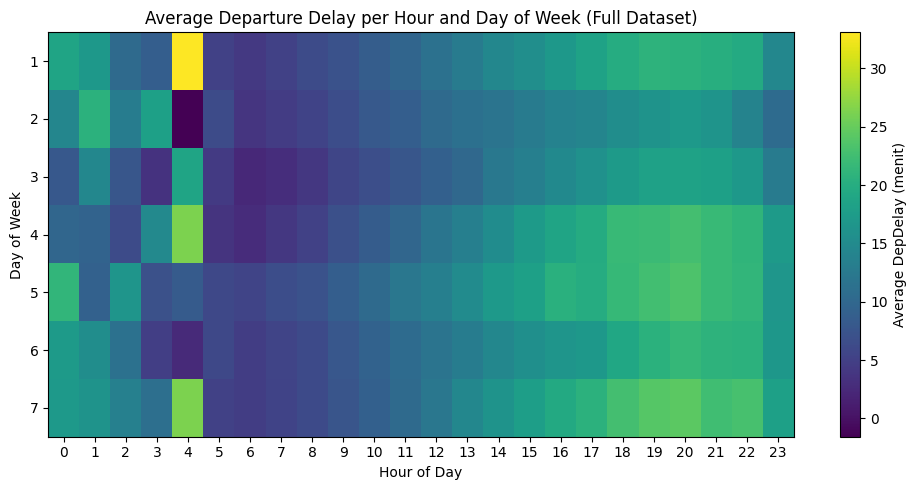

Heatmap dihasilkan dari full dataset (~7 juta baris), bukan subset JFK.


In [9]:
# Gunakan df (full dataset), toPandas() HANYA setelah groupBy agregasi kecil
df_model = df   # alias — df sudah full data, tidak ada filter JFK

df_hour = df_model.withColumn(
    "Hour",
    F_floor(col("CRSDepTime") / 100).cast("int")
)

hour_grouped = (
    df_hour
    .filter(
        col("DayOfWeek").isNotNull() &
        col("Hour").isNotNull() &
        col("DepDelay").isNotNull() &
        (col("Hour") >= 0) &
        (col("Hour") <= 23)
    )
    .groupBy("DayOfWeek", "Hour")
    .agg(F_avg("DepDelay").alias("avg(DepDelay)"))
    .orderBy("DayOfWeek", "Hour")
)

# toPandas() AMAN — hasil groupBy sudah kecil (7 hari x 24 jam = 168 baris)
dh = hour_grouped.toPandas()
c  = dh.pivot(index='DayOfWeek', columns='Hour', values='avg(DepDelay)')

X = c.columns.values
Y = c.index.values
Z = c.values

plt.figure(figsize=(10, 5))
plt.xticks(range(0, len(X)), X)
plt.yticks(range(0, len(Y)), Y)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Average Departure Delay per Hour and Day of Week (Full Dataset)')
plt.imshow(Z, aspect='auto')
plt.colorbar(label='Average DepDelay (menit)')
plt.tight_layout()
plt.show()
print("Heatmap dihasilkan dari full dataset (~7 juta baris), bukan subset JFK.")

## A4. EDA — Top Airport dan Route Delay

In [10]:
# Agregasi per Origin — toPandas() aman, hasil kecil
df_model.createOrReplaceTempView("airlineDF")

grouped_delay = sqlContext.sql(
    "SELECT Origin, count(*) AS conFlight, avg(DepDelay) AS delay "
    "FROM airlineDF GROUP BY Origin"
)
df_origin = grouped_delay.toPandas()
print("Jumlah airport unik:", len(df_origin))
df_origin.sort_values('delay', ascending=False).head(10)

Jumlah airport unik: 348


,Origin,conFlight,delay
346,MGW,37,72.621622
343,EWN,47,68.404255
302,HTS,412,42.788835
257,SMX,106,40.509434
280,CKB,202,37.024752
187,OTH,341,35.348974
102,HGR,287,35.118467
145,PBG,481,27.677755
338,HYA,261,26.636015
230,DEC,762,26.267717


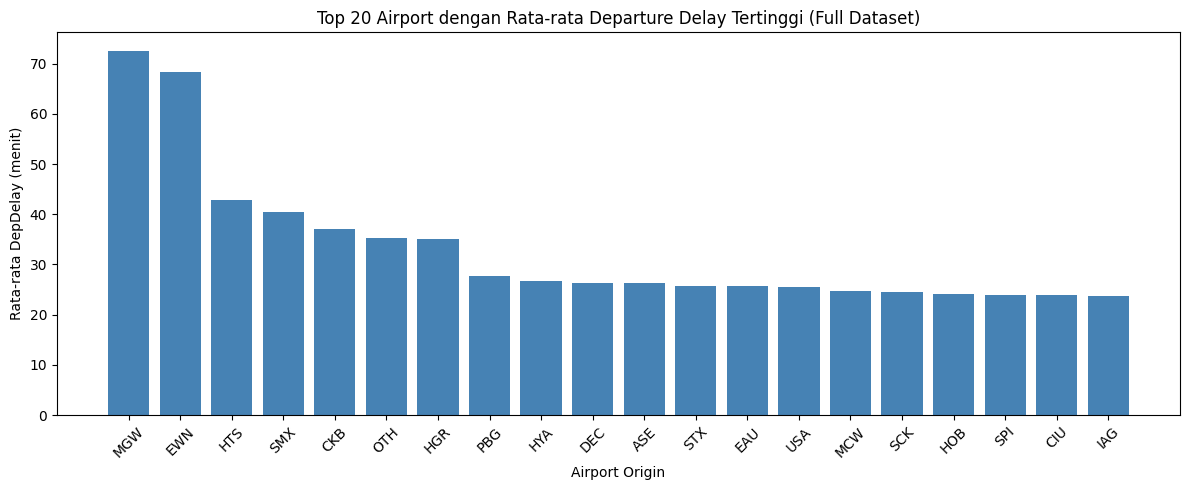

In [11]:
# Plot top 20 airport by average delay
top20 = df_origin.sort_values('delay', ascending=False).head(20)
plt.figure(figsize=(12, 5))
plt.bar(top20['Origin'], top20['delay'], color='steelblue')
plt.xlabel('Airport Origin')
plt.ylabel('Rata-rata DepDelay (menit)')
plt.title('Top 20 Airport dengan Rata-rata Departure Delay Tertinggi (Full Dataset)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## A5. Spark-ML Pipeline — Preprocessing

In [12]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

_t_pre0 = time.time()

# ─── StringIndexer untuk setiap kolom kategorikal ────────────────────────────
si_carrier = StringIndexer(inputCol="UniqueCarrier", outputCol="carrier_idx",
                            handleInvalid="keep")
si_origin  = StringIndexer(inputCol="Origin",        outputCol="origin_idx",
                            handleInvalid="keep")
si_dest    = StringIndexer(inputCol="Dest",          outputCol="dest_idx",
                            handleInvalid="keep")

# ─── OneHotEncoder ────────────────────────────────────────────────────────────
ohe = OneHotEncoder(
    inputCols  = ["carrier_idx", "origin_idx", "dest_idx"],
    outputCols = ["carrier_ohe", "origin_ohe",  "dest_ohe"]
)

# ─── VectorAssembler ──────────────────────────────────────────────────────────
assembler = VectorAssembler(
    inputCols = FEATURE_COLS_NUM + ["carrier_ohe", "origin_ohe", "dest_ohe"],
    outputCol = "features_raw",
    handleInvalid = "skip"
)

# ─── StandardScaler ───────────────────────────────────────────────────────────
scaler = StandardScaler(
    inputCol  = "features_raw",
    outputCol = "features",
    withMean  = False,   # withMean=False agar sparse vector tetap sparse
    withStd   = True
)

# ─── Logistic Regression ──────────────────────────────────────────────────────
lr = LogisticRegression(
    labelCol   = "label",
    featuresCol= "features",
    maxIter    = 20,
    regParam   = 0.01,
    elasticNetParam = 0.0
)

# ─── Full Spark-ML Pipeline ───────────────────────────────────────────────────
spark_pipeline = Pipeline(stages=[si_carrier, si_origin, si_dest, ohe, assembler, scaler, lr])

print("Spark-ML pipeline defined.")

Spark-ML pipeline defined.


In [13]:
# ─── Train/Test Split (70/30) ────────────────────────────────────────────────
# df_model = df (FULL DATASET — tidak ada filter JFK, tidak ada downsampling)
trainDF, testDF = df_model.randomSplit([0.7, 0.3], seed=42)

timings["Spark-ML"]["data_preprocessing"] = time.time() - _t_pre0
print(f"[Spark-ML] Preprocessing time (pipeline build + split): {timings['Spark-ML']['data_preprocessing']:.2f} s")
print(f"Train size (approx): {trainDF.count():,}")
print(f"Test  size (approx): {testDF.count():,}")

[Spark-ML] Preprocessing time (pipeline build + split): 0.19 s
Train size (approx): 4,888,470
Test  size (approx): 2,097,641


## A6. Spark-ML — Training

In [14]:
_t_train0 = time.time()

spark_model = spark_pipeline.fit(trainDF)

timings["Spark-ML"]["model_training"] = time.time() - _t_train0
print(f"[Spark-ML] Training time: {timings['Spark-ML']['model_training']:.2f} s")

[Spark-ML] Training time: 199.43 s


## A7. Spark-ML — Inference & Evaluasi

In [15]:
_t_inf0 = time.time()

predictions = spark_model.transform(testDF)
_ = predictions.count()   # force evaluation

timings["Spark-ML"]["inference"] = time.time() - _t_inf0
print(f"[Spark-ML] Inference time: {timings['Spark-ML']['inference']:.2f} s")

[Spark-ML] Inference time: 14.44 s


In [16]:
# ─── Metrik Spark-ML ─────────────────────────────────────────────────────────
eval_auc  = BinaryClassificationEvaluator(labelCol="label",
                                          rawPredictionCol="rawPrediction",
                                          metricName="areaUnderROC")
eval_auprc = BinaryClassificationEvaluator(labelCol="label",
                                           rawPredictionCol="rawPrediction",
                                           metricName="areaUnderPR")
eval_acc  = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              metricName="weightedPrecision")
eval_rec  = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              metricName="weightedRecall")
eval_f1   = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              metricName="f1")

metrics["Spark-ML"]["accuracy"]  = eval_acc.evaluate(predictions)
metrics["Spark-ML"]["precision"] = eval_prec.evaluate(predictions)
metrics["Spark-ML"]["recall"]    = eval_rec.evaluate(predictions)
metrics["Spark-ML"]["f1"]        = eval_f1.evaluate(predictions)
metrics["Spark-ML"]["auc"]       = eval_auc.evaluate(predictions)
metrics["Spark-ML"]["auprc"]     = eval_auprc.evaluate(predictions)

# Simpan AUC full data — agar tidak tertimpa oleh AUC sample di cell ROC plotting
auc_sp_full = metrics["Spark-ML"]["auc"]

print("=== METRIK SPARK-ML ===")
for k, v in metrics["Spark-ML"].items():
    print(f"  {k:12s}: {v:.4f}")

=== METRIK SPARK-ML ===
  accuracy    : 0.8092
  precision   : 0.8222
  recall      : 0.8092
  f1          : 0.7353
  auc         : 0.7057
  auprc       : 0.4211


## A8. Spark-ML — Confusion Matrix

   label  prediction    count
0      0         0.0  1673746
1      0         1.0     3298
2      1         0.0   396972
3      1         1.0    23625


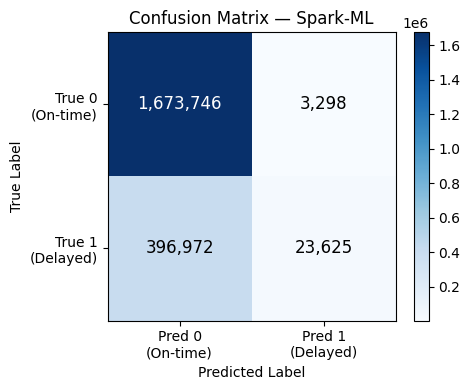

In [17]:
# toPandas() AMAN — hanya 4 baris (2x2 confusion matrix)
cm_spark_df = (
    predictions
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
    .toPandas()
)
print(cm_spark_df)

# Pivot menjadi matrix 2x2
cm_spark = cm_spark_df.pivot(index='label', columns='prediction', values='count').fillna(0).values.astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_spark, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0\n(On-time)', 'Pred 1\n(Delayed)'])
ax.set_yticklabels(['True 0\n(On-time)', 'True 1\n(Delayed)'])
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Spark-ML')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_spark[i,j]:,}', ha='center', va='center',
                fontsize=12, color='white' if cm_spark[i,j] > cm_spark.max()/2 else 'black')
plt.tight_layout()
plt.show()

## A9. Spark-ML — ROC Curve

ROC sample size: 50,304 baris


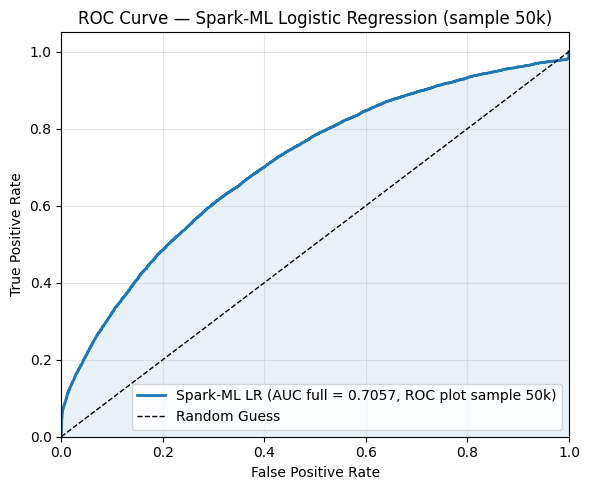

[Spark-ML] ROC-AUC full data  : 0.7057
[Spark-ML] ROC-AUC sample plot: 0.7079


In [18]:
# ROC Curve Spark-ML — pakai sample kecil (50k baris) dari predictions untuk plotting
# Pendekatan ini jauh lebih efisien daripada 101 Spark job (1 per threshold)
# dan jauh lebih aman daripada toPandas() pada 2 juta baris penuh.
# Sample 50k sudah cukup untuk kurva ROC yang representatif.
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
from sklearn.metrics import roc_curve, auc as sk_auc
import numpy as np

get_prob_1 = udf(lambda v: float(v[1]), DoubleType())

# Hitung rasio sample: target 50_000 baris dari test set
n_test   = predictions.count()
fraction = min(1.0, 50_000 / n_test)

# toPandas() AMAN — hanya 50k baris (2 kolom float)
roc_sample = (
    predictions
    .select(
        get_prob_1(col("probability")).alias("score"),
        col("label").cast("double").alias("label")
    )
    .sample(fraction=fraction, seed=42)
    .toPandas()
)
print(f"ROC sample size: {len(roc_sample):,} baris")

fpr_sp, tpr_sp, _ = roc_curve(roc_sample["label"], roc_sample["score"])
auc_sp_sample = sk_auc(fpr_sp, tpr_sp)

# JANGAN timpa metrics["Spark-ML"]["auc"] — tabel metrik tetap pakai AUC full data
# auc_sp_full sudah tersimpan dari cell evaluasi sebelumnya
auc_sp = auc_sp_full

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_sp, tpr_sp, lw=2,
        label=f"Spark-ML LR (AUC full = {auc_sp_full:.4f}, ROC plot sample 50k)")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess")
ax.fill_between(fpr_sp, tpr_sp, alpha=0.1)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Spark-ML Logistic Regression (sample 50k)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"[Spark-ML] ROC-AUC full data  : {auc_sp_full:.4f}")
print(f"[Spark-ML] ROC-AUC sample plot: {auc_sp_sample:.4f}")

---
# BAGIAN B — Local Pipeline (Pandas + scikit-learn SGDClassifier)

> **Full dataset ~7 juta baris, tidak ada filter JFK, tidak ada downsampling.**  
> Menggunakan `SGDClassifier(loss='log_loss')` (online learning, memory-efficient)  
> dan `OneHotEncoder(sparse_output=True)` untuk menghindari dense matrix.

## B1. Data Loading (Local)

In [19]:
# Kolom yang dibutuhkan saja — hemat memori
LOCAL_NUM_COLS = ["month", "day_of_month", "day_of_week", "dep_time",
                  "crs_dep_time", "arr_time", "crs_arr_time", "distance"]
LOCAL_CAT_COLS = ["op_unique_carrier", "origin", "dest"]
LOCAL_TARGET   = "dep_delay"

_t0 = time.time()

df_local = pd.read_csv(
    flight_csv,
    usecols  = LOCAL_NUM_COLS + LOCAL_CAT_COLS + [LOCAL_TARGET],
    dtype    = {
        "month": "int8", "day_of_month": "int8", "day_of_week": "int8",
        "op_unique_carrier": "category", "origin": "category", "dest": "category"
    },
    low_memory = False
)

timings["Local"]["data_loading"] = time.time() - _t0
print(f"[Local] Data loading time: {timings['Local']['data_loading']:.2f} s")
print(f"[Local] Jumlah data awal : {len(df_local):,}")
df_local.head(3)

[Local] Data loading time: 21.65 s
[Local] Jumlah data awal : 7,079,081


,month,day_of_month,day_of_week,op_unique_carrier,origin,dest,crs_dep_time,dep_time,dep_delay,crs_arr_time,arr_time,distance
0,1,1,1,9E,JFK,DTW,1252,1247.0,-5.0,1508,1449.0,509.0
1,1,1,1,9E,MSP,CLE,1015,1001.0,-14.0,1325,1255.0,622.0
2,1,1,1,9E,JFK,RIC,1415,1411.0,-4.0,1601,1541.0,288.0


## B2. Preprocessing (Local)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

_t0 = time.time()

# 1. Drop baris dengan DepDelay kosong
df_local = df_local.dropna(subset=[LOCAL_TARGET])

# 2. Buat label biner
df_local["label"] = (df_local[LOCAL_TARGET] > 15).astype("int8")

# 3. Isi NaN numerik dengan 0 (tidak menggunakan imputer tersendiri agar hemat)
for c in LOCAL_NUM_COLS:
    df_local[c] = pd.to_numeric(df_local[c], errors='coerce').fillna(0)

# 4. Isi NaN kategorikal dengan 'UNKNOWN'
for c in LOCAL_CAT_COLS:
    df_local[c] = df_local[c].astype(str).fillna("UNKNOWN")

X = df_local[LOCAL_NUM_COLS + LOCAL_CAT_COLS]
y = df_local["label"]

# Rename num cols agar lebih deskriptif
X.columns = ["Month","DayofMonth","DayOfWeek","DepTime",
              "CRSDepTime","ArrTime","CRSArrTime","Distance",
              "UniqueCarrier","Origin","Dest"]

FEAT_NUM = ["Month","DayofMonth","DayOfWeek","DepTime",
            "CRSDepTime","ArrTime","CRSArrTime","Distance"]
FEAT_CAT = ["UniqueCarrier","Origin","Dest"]

print(f"[Local] Jumlah data setelah preprocessing : {len(X):,}")
print(f"[Local] Distribusi label:\n{y.value_counts().to_string()}")

# 5. Train/Test split — 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"[Local] Train: {len(X_train):,} | Test: {len(X_test):,}")

timings["Local"]["data_preprocessing"] = time.time() - _t0
print(f"[Local] Preprocessing time: {timings['Local']['data_preprocessing']:.2f} s")

[Local] Jumlah data setelah preprocessing : 6,986,111
[Local] Distribusi label:
label
0    5589027
1    1397084
[Local] Train: 4,890,277 | Test: 2,095,834
[Local] Preprocessing time: 18.49 s


## B3. Training (Local — SGDClassifier)

In [21]:
# ColumnTransformer — fit HANYA pada data train (hindari data leakage)
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), FEAT_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), FEAT_CAT),
])

# SGDClassifier: online learning, memory-efficient untuk 7 juta baris
# loss='log_loss' -> setara Logistic Regression
sgd = SGDClassifier(
    loss       = "log_loss",
    max_iter   = 1000,
    tol        = 1e-3,
    random_state = 42,
    n_jobs     = -1
)

local_pipeline = SkPipeline([
    ("preprocessor", preprocessor),
    ("classifier",   sgd)
])

_t0 = time.time()

local_pipeline.fit(X_train, y_train)

timings["Local"]["model_training"] = time.time() - _t0
print(f"[Local] Training time: {timings['Local']['model_training']:.2f} s ({len(X_train):,} baris)")

[Local] Training time: 28.28 s (4,890,277 baris)


## B4. Inference & Evaluasi (Local)

In [22]:
_t0 = time.time()

y_pred  = local_pipeline.predict(X_test)
y_proba = local_pipeline.predict_proba(X_test)[:, 1]

timings["Local"]["inference"] = time.time() - _t0
print(f"[Local] Inference time: {timings['Local']['inference']:.4f} s ({len(X_test):,} baris)")

metrics["Local"]["accuracy"]  = accuracy_score(y_test, y_pred)
metrics["Local"]["precision"] = precision_score(y_test, y_pred, average='weighted', zero_division=0)
metrics["Local"]["recall"]    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
metrics["Local"]["f1"]        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
metrics["Local"]["auc"]       = roc_auc_score(y_test, y_proba)

from sklearn.metrics import average_precision_score
metrics["Local"]["auprc"]     = average_precision_score(y_test, y_proba)

print("\n=== METRIK LOCAL ===")
for k, v in metrics["Local"].items():
    print(f"  {k:12s}: {v:.4f}")

[Local] Inference time: 9.9540 s (2,095,834 baris)

=== METRIK LOCAL ===
  accuracy    : 0.8405
  precision   : 0.8624
  recall      : 0.8405
  f1          : 0.7960
  auc         : 0.8455
  auprc       : 0.7016


## B5. Confusion Matrix (Local)

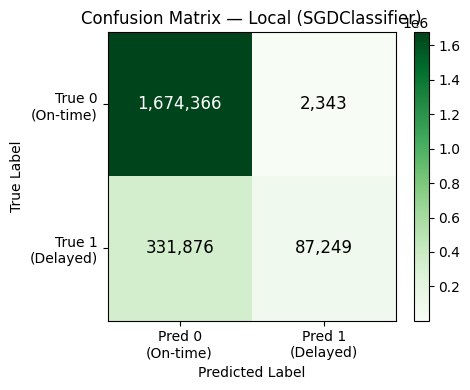

In [23]:
cm_local = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_local, interpolation='nearest', cmap='Greens')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0\n(On-time)', 'Pred 1\n(Delayed)'])
ax.set_yticklabels(['True 0\n(On-time)', 'True 1\n(Delayed)'])
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Local (SGDClassifier)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_local[i,j]:,}', ha='center', va='center',
                fontsize=12, color='white' if cm_local[i,j] > cm_local.max()/2 else 'black')
plt.tight_layout()
plt.show()

## B6. ROC Curve (Local)

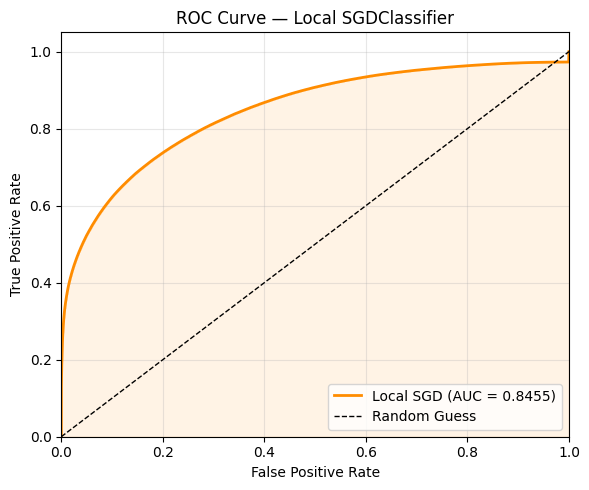

[Local] AUC: 0.8455


In [24]:
from sklearn.metrics import auc as sk_auc

fpr_loc, tpr_loc, _ = roc_curve(y_test, y_proba)
auc_loc = sk_auc(fpr_loc, tpr_loc)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_loc, tpr_loc, color='darkorange', lw=2,
        label=f'Local SGD (AUC = {auc_loc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
ax.fill_between(fpr_loc, tpr_loc, alpha=0.1, color='darkorange')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Local SGDClassifier')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"[Local] AUC: {auc_loc:.4f}")

---
# BAGIAN C — Perbandingan Local vs Spark-ML

## C1. Ringkasan Data

In [25]:
print("=" * 55)
print("RINGKASAN DATA")
print("=" * 55)
print(f"  Dataset          : Flight Data 2024 (FULL — tanpa filter JFK)")
print(f"  Jumlah data awal : {_n:,} baris (Spark count)")
print(f"  Jumlah kolom     : {len(ALL_COLS)} kolom yang digunakan")
print(f"  Target           : label (1=delay>15mnt, 0=on-time)")
print(f"  [Local] Train    : {len(X_train):,} | Test: {len(X_test):,}")
print("=" * 55)

RINGKASAN DATA
  Dataset          : Flight Data 2024 (FULL — tanpa filter JFK)
  Jumlah data awal : 6,986,111 baris (Spark count)
  Jumlah kolom     : 13 kolom yang digunakan
  Target           : label (1=delay>15mnt, 0=on-time)
  [Local] Train    : 4,890,277 | Test: 2,095,834


## C2. Tabel Perbandingan Metrik

In [26]:
metric_keys = ["accuracy", "precision", "recall", "f1", "auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

comparison_metrics = pd.DataFrame({
    "Metrik"    : metric_labels,
    "Local"     : [metrics["Local"].get(k, np.nan)    for k in metric_keys],
    "Spark-ML"  : [metrics["Spark-ML"].get(k, np.nan) for k in metric_keys],
})
comparison_metrics["Selisih (Local-Spark)"] = comparison_metrics["Local"] - comparison_metrics["Spark-ML"]
print(comparison_metrics.to_string(index=False, float_format="{:.4f}".format))

   Metrik  Local  Spark-ML  Selisih (Local-Spark)
 Accuracy 0.8405    0.8092                 0.0314
Precision 0.8624    0.8222                 0.0403
   Recall 0.8405    0.8092                 0.0314
 F1-Score 0.7960    0.7353                 0.0607
  ROC-AUC 0.8455    0.7057                 0.1398


## C3. Tabel Perbandingan Waktu

In [27]:
stages_time = ["data_loading", "data_preprocessing", "model_training", "inference"]
stage_labels = ["(a) Data Loading", "(b) Preprocessing", "(c) Training", "(d) Inference"]

comparison_time = pd.DataFrame({
    "Tahap"       : stage_labels,
    "Local (s)"   : [timings["Local"].get(s, np.nan)    for s in stages_time],
    "Spark-ML (s)": [timings["Spark-ML"].get(s, np.nan) for s in stages_time],
})
comparison_time["Total Local (s)"]    = comparison_time["Local (s)"].sum()
comparison_time["Total Spark-ML (s)"] = comparison_time["Spark-ML (s)"].sum()

print(comparison_time[["Tahap", "Local (s)", "Spark-ML (s)"]].to_string(index=False, float_format="{:.3f}".format))
print(f"\nTotal Local    : {comparison_time['Local (s)'].sum():.3f} s")
print(f"Total Spark-ML : {comparison_time['Spark-ML (s)'].sum():.3f} s")

            Tahap  Local (s)  Spark-ML (s)
 (a) Data Loading     21.646       173.112
(b) Preprocessing     18.490         0.186
     (c) Training     28.281       199.427
    (d) Inference      9.954        14.436

Total Local    : 78.371 s
Total Spark-ML : 387.161 s


## C4. Grafik Perbandingan Metrik

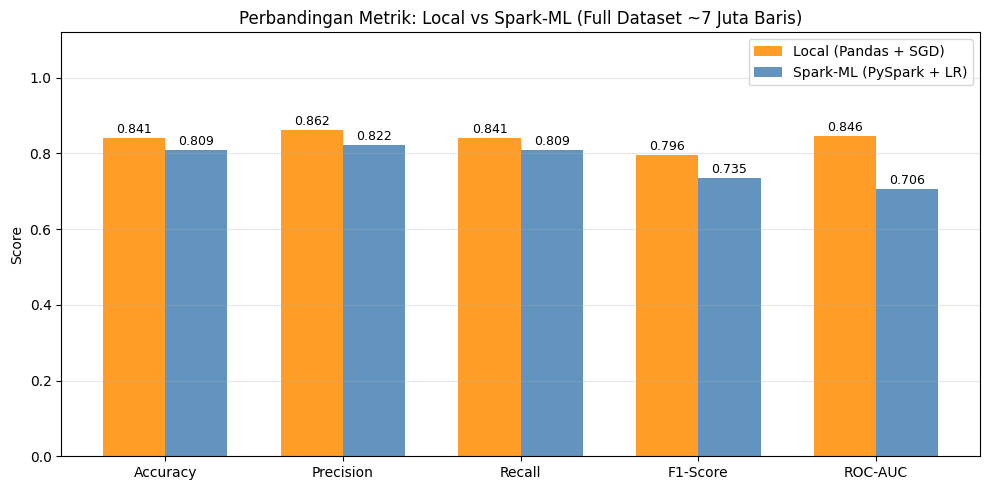

In [28]:
x      = np.arange(len(metric_labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_metrics["Local"],   width,
               label='Local (Pandas + SGD)', color='darkorange', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_metrics["Spark-ML"], width,
               label='Spark-ML (PySpark + LR)', color='steelblue', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik: Local vs Spark-ML (Full Dataset ~7 Juta Baris)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## C5. Grafik Perbandingan Waktu Komputasi

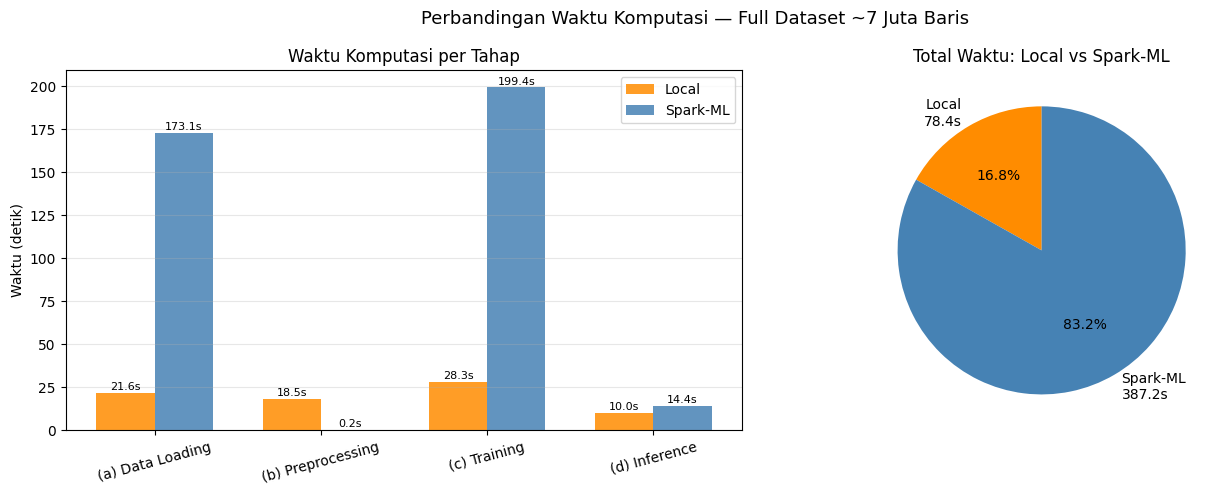

In [29]:
local_times  = [timings["Local"].get(s, 0)    for s in stages_time]
spark_times  = [timings["Spark-ML"].get(s, 0) for s in stages_time]

x     = np.arange(len(stage_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grouped bar ──────────────────────────────────────────────────────────────
b1 = axes[0].bar(x - width/2, local_times, width, label='Local',    color='darkorange', alpha=0.85)
b2 = axes[0].bar(x + width/2, spark_times, width, label='Spark-ML', color='steelblue',  alpha=0.85)
for b in list(b1)+list(b2):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f'{b.get_height():.1f}s', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(stage_labels, rotation=15)
axes[0].set_ylabel('Waktu (detik)')
axes[0].set_title('Waktu Komputasi per Tahap')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Total time pie ────────────────────────────────────────────────────────────
totals = [sum(local_times), sum(spark_times)]
labels_pie = [
    f'Local\n{totals[0]:.1f}s',
    f'Spark-ML\n{totals[1]:.1f}s'
]
axes[1].pie(totals, labels=labels_pie, autopct='%1.1f%%',
            colors=['darkorange', 'steelblue'], startangle=90)
axes[1].set_title('Total Waktu: Local vs Spark-ML')

plt.suptitle('Perbandingan Waktu Komputasi — Full Dataset ~7 Juta Baris', fontsize=13)
plt.tight_layout()
plt.show()

## C6. ROC Curve — Overlay Local vs Spark-ML

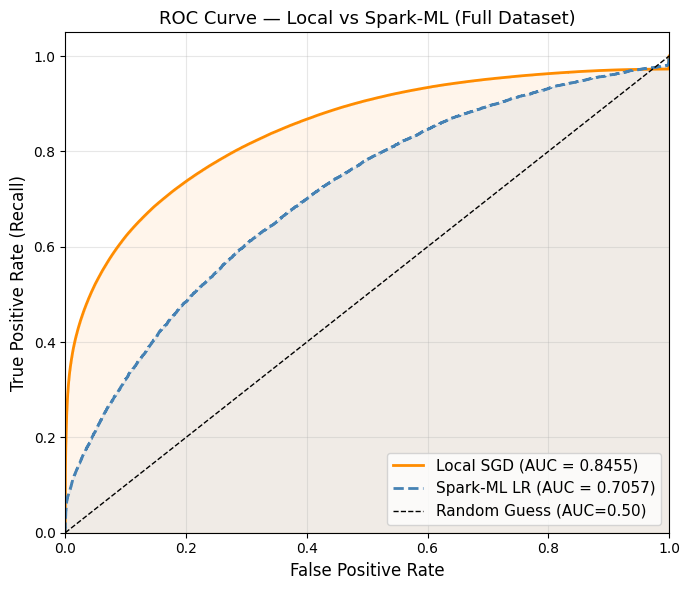

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_loc, tpr_loc, color='darkorange', lw=2,
        label=f'Local SGD (AUC = {auc_loc:.4f})')
ax.plot(fpr_sp, tpr_sp,  color='steelblue',  lw=2, linestyle='--',
        label=f'Spark-ML LR (AUC = {auc_sp:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC=0.50)')

ax.fill_between(fpr_loc, tpr_loc, alpha=0.08, color='darkorange')
ax.fill_between(fpr_sp,  tpr_sp,  alpha=0.08, color='steelblue')

ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Local vs Spark-ML', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# BAGIAN D — Analisis Komparatif (Laporan Singkat)

## D.1 Waktu Komputasi Spark-ML per Tahap (Chart Detail)

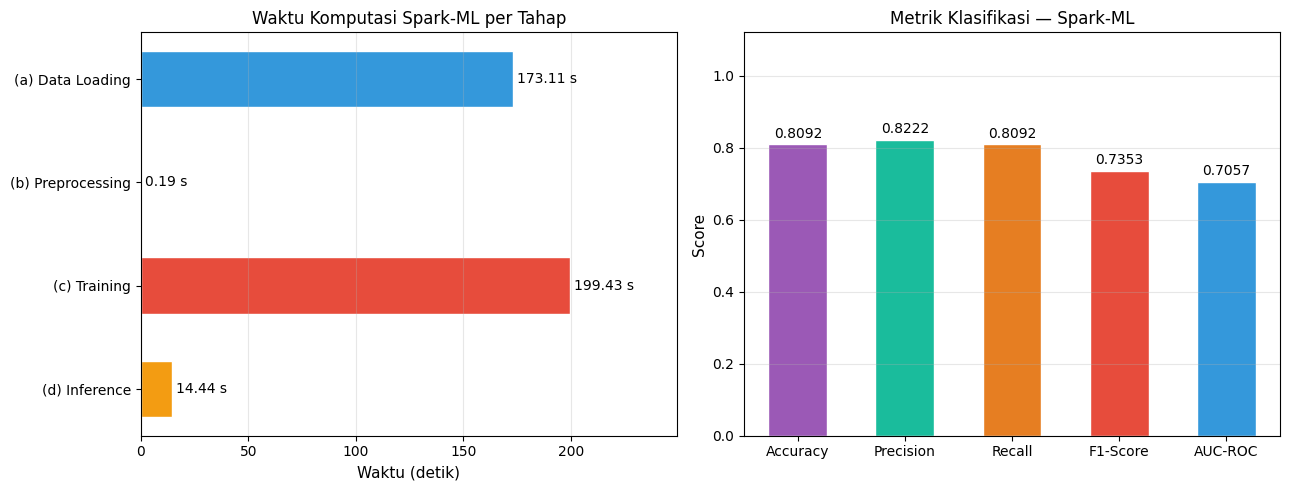

In [32]:
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Spark-ML per tahap ──────────────────────────────────────────────────
bars = axes[0].barh(stage_labels, spark_times, color=colors_bar,
                    edgecolor='white', height=0.55)
for bar, val in zip(bars, spark_times):
    axes[0].text(bar.get_width() + max(spark_times)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} s', va='center', fontsize=10)
axes[0].set_xlabel('Waktu (detik)', fontsize=11)
axes[0].set_title('Waktu Komputasi Spark-ML per Tahap', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, max(spark_times) * 1.25 if max(spark_times) > 0 else 1)

# ── Right: Metrik Spark-ML ────────────────────────────────────────────────────
metric_names_chart  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_values_chart = [metrics["Spark-ML"][k] for k in ["accuracy","precision","recall","f1","auc"]]
bar_colors2 = ['#9b59b6', '#1abc9c', '#e67e22', '#e74c3c', '#3498db']

axes[1].bar(metric_names_chart, metric_values_chart, color=bar_colors2,
            edgecolor='white', width=0.55)
for i, val in enumerate(metric_values_chart):
    axes[1].text(i, val + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Metrik Klasifikasi — Spark-ML', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Menutup Sesi Spark

In [33]:
spark.stop()
print("Spark session stopped. Notebook selesai.")

Spark session stopped. Notebook selesai.
